Multi-Head Attention (MHA)

| Layman Term                       | Technical Term                         |
| --------------------------------- | -------------------------------------- |
| Employee                          | Query Head                             |
| Expert                            | Key/Value Head                         |
| Each employee has separate expert | Each Query head has separate K/V heads |

Example

| Query Head | Key/Value Head |
| ---------- | -------------- |
| Q1         | K1, V1         |
| Q2         | K2, V2         |
| Q3         | K3, V3         |
| Q4         | K4, V4         |

- Total Query Heads = 4
- Total KV Heads = 4

---

Multi-Query Attention (MQA)

| Layman Term                    | Technical Term                    |
| ------------------------------ | --------------------------------- |
| All employees share one expert | All Query heads share one KV head |

Example

| Query Heads    | Shared Key/Value Head |
| -------------- | --------------------- |
| Q1, Q2, Q3, Q4 | K1, V1                |

- Total Query Heads = 4
- Total KV Heads = 1

---

Grouped Query Attention (GQA)

| Layman Term                         | Technical Term                       |
| ----------------------------------- | ------------------------------------ |
| Small employee groups share experts | Groups of Query heads share KV heads |

Example

| Query Head Group | Shared Key/Value Head |
| ---------------- | --------------------- |
| Q1, Q2           | K1, V1                |
| Q3, Q4           | K2, V2                |

- Total Query Heads = 4
- Total KV Heads = 2

---

Memory Impact

| Method | Query Heads | KV Heads | KV Cache Size |
| ------ | ----------- | -------- | ------------- |
| MHA    | 4           | 4        | Highest       |
| GQA    | 4           | 2        | Medium        |
| MQA    | 4           | 1        | Lowest        |

---

Core Technical Insight

KV cache memory depends mainly on:

```text
Number of KV Heads × Sequence Length × Hidden Dimension
```

So reducing KV heads:

- lowers memory usage
- speeds up inference
- improves scalability for long-context generation.


Summary

Grouped Query Attention (GQA) is a technique designed to reduce the size of the Key-Value (KV) cache in transformer models without significantly compromising model quality. This method balances the benefits of Multi-Head Attention (MHA) and Multi-Query Attention (MQA) by sharing Key and Value matrices across groups of Query heads. GQA has been adopted in many high-performance language models, such as the Llama family, to enhance efficiency in memory usage and inference speed.


Key Concepts

1. Understanding KV Caching
KV caching improves token generation speed by reusing Key and Value vectors.
Large cache sizes can lead to memory consumption issues, especially with long sequences.

2. Multi-Head Attention (MHA)
MHA uses multiple independent attention heads, each with its own Key, Value, and Query matrices.
Each layer and token requires storing K and V vectors for every head, leading to large cache sizes.

3. Multi-Query Attention (MQA)
MQA reduces cache size by sharing a single set of Key and Value matrices across multiple Query heads.
This approach significantly decreases memory usage but may lead to a drop in model quality.

4. Grouped Query Attention (GQA)
GQA shares Key and Value matrices across groups of Query heads, maintaining separate Query matrices.
For example, with 32 Query heads divided into 8 groups, each group shares one K/V head.


Benefits of GQA

- Reduced KV Cache Size: Cache size is significantly smaller compared to MHA, improving memory efficiency.
- Faster Inference: Less data to read from memory reduces memory bandwidth requirements, speeding up inference.
- Maintained Quality: GQA achieves quality closer to MHA, providing a better trade-off between speed, memory, and performance.


Step-by-Step Instructions for Implementation

1. Identify the Number of Query Heads: Determine the total number of Query heads (N) in the model.
2. Decide on Group Size: Choose the number of groups (G) for sharing K/V heads. For example, if N is 32, G could be 8.
3. Group the Query Heads: Divide the Query heads into G groups. Each group will share one K/V head.
   Example: 32 Query heads can be grouped into 8 groups of 4 heads each.
4. Implement Shared K/V Heads: Modify the model architecture to ensure that each group of Query heads accesses the same K/V head.
5. Test Model Performance: Evaluate the model to ensure that the quality remains high while benefiting from reduced cache size and faster inference.


Takeaways

- GQA effectively reduces the size of the KV cache while maintaining model quality, making it a valuable technique in modern transformer architectures.
- Many high-performance models, such as Llama, utilize GQA to enhance efficiency in both memory usage and inference speed.


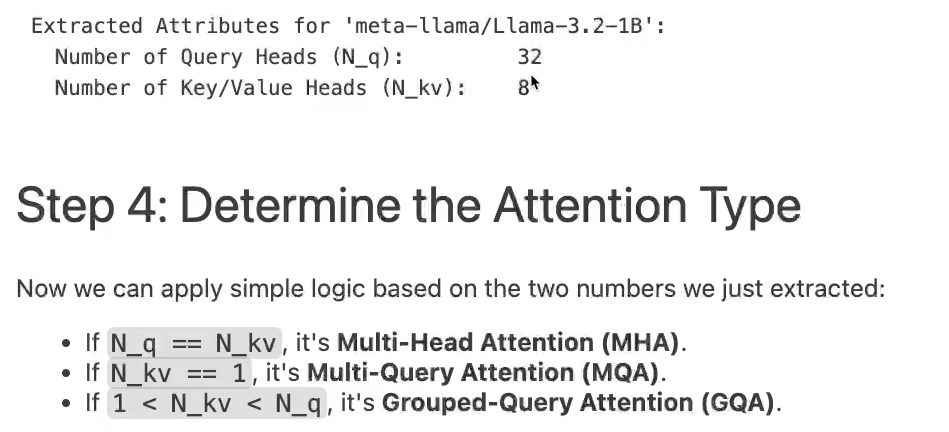

query heads = 32
1. MHA = head = 32
2. MQA = head = 1
3. GQA = head = 4 (if 8 groups)

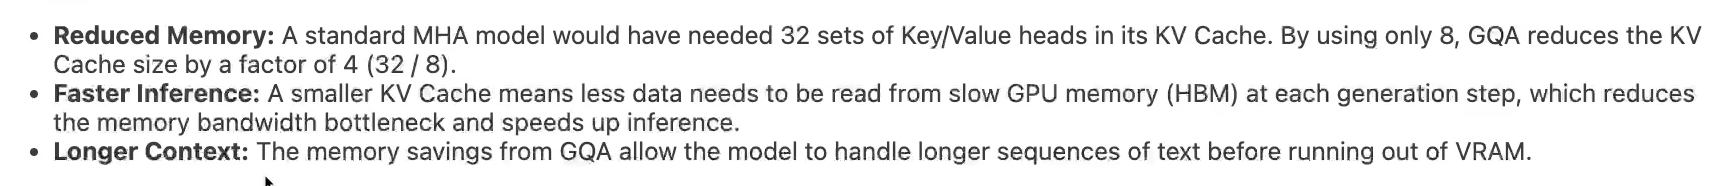

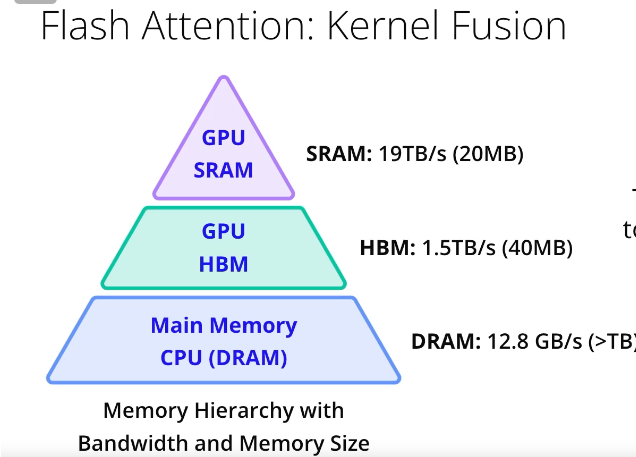

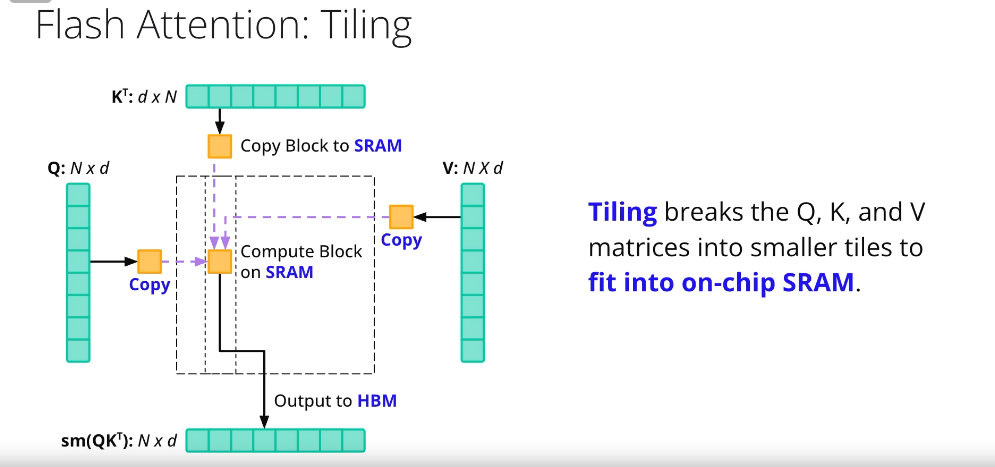

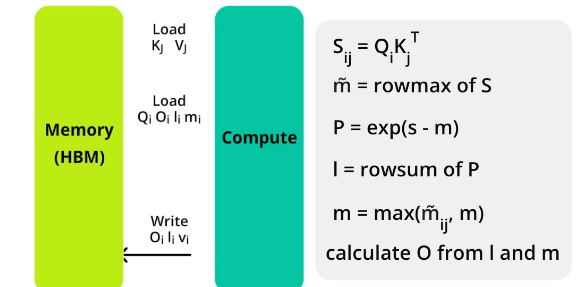

Attention Calculation — Short Summary

Core Concepts

- Query (Q) → What current word is searching for
- Key (K) → What each word contains
- Value (V) → Actual information of the word
- Attention Score → Relevance between words
- Softmax → Converts scores into importance %
- Output → Weighted combination of important words

---

Attention Calculation Flow

| Step | Operation      | Purpose                      |
| ---- | -------------- | ---------------------------- |
| 1    | Create Q, K, V | Represent word meaning       |
| 2    | Q × K          | Calculate relevance          |
| 3    | Softmax        | Convert to attention weights |
| 4    | Weight × V     | Extract useful information   |
| 5    | Sum            | Generate contextual output   |

---

Example

Current word: "drank"

| Word | Score (Q×K) | Attention % | Value (V) | Contribution |
| ---- | ----------- | ----------- | --------- | ------------ |
| The  | 3           | 1%          | 2         | 0.02         |
| cat  | 12          | 27%         | 10        | 2.70         |
| milk | 15          | 72%         | 20        | 14.40        |

---

Final Output

| Calculation         | Result |
| ------------------- | ------ |
| 0.02 + 2.70 + 14.40 | 17.12  |

---

Intuition

The model learns: "drank" is mostly related to "milk" and somewhat related to "cat".


Introduction
Flash Attention is an advanced algorithm designed to optimize the self-attention mechanism used in transformer models. It addresses the significant memory bandwidth bottleneck that arises during attention computation, particularly for long sequences. By minimizing data movement between GPU cores and High Bandwidth Memory (HBM), Flash Attention enhances performance and efficiency.

Summary
The standard self-attention mechanism involves computing large intermediate matrices, which can become a bottleneck due to the high memory bandwidth required. Flash Attention introduces three key techniques—Tiling, Kernel Fusion, and Recomputation—to optimize this process. These techniques reduce memory access complexity and improve computational speed, making Flash Attention a vital tool for efficient transformer inference and training.

Techniques of Flash Attention
1. Tiling
Breaks down Q, K, and V matrices into smaller blocks (e.g., 64×64).
Computes attention scores block-by-block, keeping data local to on-chip SRAM.
Reduces the amount of data loaded from and written to HBM.
2. Kernel Fusion
Combines three separate operations (score computation, softmax application, and value multiplication) into a single GPU kernel per tile.
Eliminates the need to write intermediate results back to memory, saving memory bandwidth and improving throughput.
3. Recomputation
Recomputes some intermediate results on the fly instead of reading them from memory.
For example, the softmax normalization factor is recalculated during the value aggregation step.
This approach reduces memory I/O by trading a small amount of computation for significant memory access savings.
Benefits of Flash Attention
Significant Speedup: Achieves 2-4x speed improvements for attention computation, especially for long sequences.
Reduced Memory Usage: Does not require storage of large intermediate matrices, allowing for longer sequences or larger batch sizes within the same GPU memory limits.
Exact Attention: Computes the same attention output as the standard algorithm without approximations.
Putting It All Together
Flash Attention effectively reduces memory access complexity from O(N²) to O(N), enabling faster and more memory-efficient attention computation. This optimization has made Flash Attention a cornerstone of efficient transformer models, with many libraries and frameworks integrating it.

Key Takeaways
Flash Attention optimizes the self-attention mechanism by minimizing memory bandwidth usage through Tiling, Kernel Fusion, and Recomputation.
It provides significant speed improvements and reduced memory usage while maintaining exact attention outputs, making it essential for modern transformer applications.

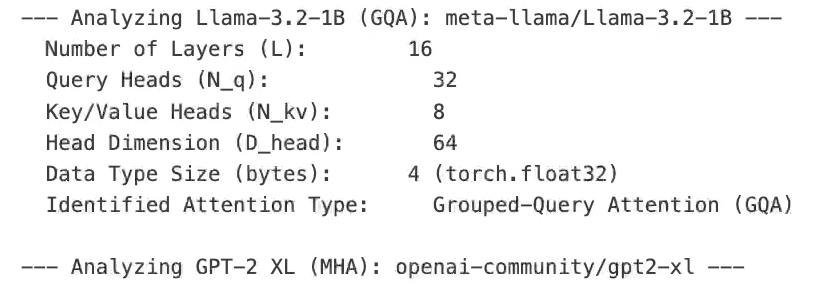

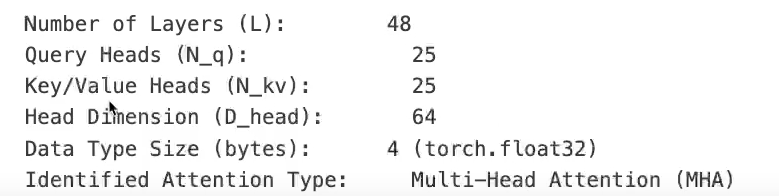

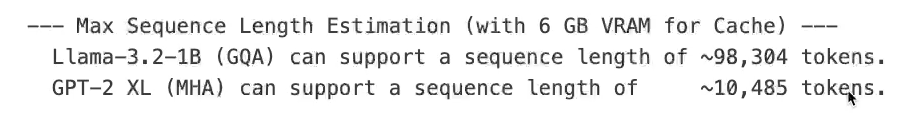